In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df=pd.read_csv('../data/raw/creditcard_model.csv')
df.head(3)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0


In [56]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250001 entries, 0 to 250000
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    250001 non-null  float64
 1   V1      250001 non-null  float64
 2   V2      250001 non-null  float64
 3   V3      250001 non-null  float64
 4   V4      250001 non-null  float64
 5   V5      250001 non-null  float64
 6   V6      250001 non-null  float64
 7   V7      250001 non-null  float64
 8   V8      250001 non-null  float64
 9   V9      250001 non-null  float64
 10  V10     250001 non-null  float64
 11  V11     250001 non-null  float64
 12  V12     250001 non-null  float64
 13  V13     250001 non-null  float64
 14  V14     250001 non-null  float64
 15  V15     250001 non-null  float64
 16  V16     250001 non-null  float64
 17  V17     250001 non-null  float64
 18  V18     250001 non-null  float64
 19  V19     250001 non-null  float64
 20  V20     250001 non-null  float64
 21  V21     25

In [33]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,250001.000000,250001.000000,250001.000000,250001.000000,250001.000000,250001.000000,250001.000000,250001.000000,250001.000000,250001.000000,250001.000000,250001.000000,250001.000000,250001.000000,250001.000000,250001.000000,250001.000000,250001.000000,250001.000000,250001.000000,250001.000000,250001.000000,250001.000000,250001.000000,250001.000000,250001.000000,250001.000000,250001.000000,250001.000000,250001.000000,250001.000000
mean,85325.502654,-0.036953,-0.020169,0.101302,0.024680,-0.037457,0.018641,-0.016305,0.002041,0.001027,-0.000906,0.041205,-0.029088,0.005654,0.016938,0.026239,-0.002485,0.009831,-0.014435,-0.003784,0.004508,-0.001805,-0.010641,-0.006312,0.000758,0.021252,0.001517,-0.000629,0.000821,90.713487,0.001832
std,42766.657629,1.959965,1.669706,1.507185,1.415289,1.375901,1.326624,1.227116,1.194669,1.112240,1.087372,1.029364,1.032265,1.010447,0.965004,0.927447,0.883142,0.863593,0.842685,0.818337,0.782598,0.738741,0.716498,0.637945,0.606224,0.515233,0.485424,0.401414,0.333065,251.606005,0.042763
min,0.000000,-56.407510,-72.715728,-33.680984,-5.683171,-42.147898,-26.160506,-43.557242,-73.216718,-13.434066,-24.588262,-4.797473,-18.683715,-5.791881,-19.214325,-4.498945,-14.129855,-25.162799,-9.498746,-7.213527,-28.009635,-34.830382,-10.933144,-44.807735,-2.836627,-10.295397,-2.604551,-22.565679,-11.710896,0.000000,0.000000
25%,50294.000000,-0.936115,-0.608885,-0.716796,-0.837192,-0.727733,-0.747953,-0.565099,-0.201625,-0.655056,-0.526721,-0.719926,-0.436615,-0.655384,-0.404484,-0.563399,-0.474743,-0.467204,-0.510116,-0.469961,-0.207204,-0.225422,-0.534058,-0.165140,-0.350868,-0.292214,-0.329895,-0.070575,-0.050494,6.000000,0.000000
50%,77503.000000,-0.004101,0.060214,0.294348,0.014077,-0.095170,-0.250496,0.020929,0.029061,-0.058540,-0.091443,0.000917,0.123321,-0.011346,0.059624,0.088031,0.063204,-0.051941,-0.017315,-0.001666,-0.056234,-0.031140,-0.000621,-0.018217,0.044959,0.051624,-0.059025,0.002343,0.013903,23.040000,0.000000
75%,127559.000000,1.264953,0.781094,1.102028,0.794534,0.566575,0.421824,0.547171,0.330616,0.607867,0.457556,0.790918,0.611632,0.672504,0.502088,0.692330,0.528368,0.407096,0.487077,0.465881,0.140311,0.177438,0.499160,0.135927,0.432165,0.364895,0.247835,0.089084,0.077757,79.900000,0.000000
max,154676.000000,2.454930,22.057729,9.382558,16.875344,34.801666,22.529298,36.877368,20.007208,15.594995,23.745136,12.018913,7.848392,4.569009,10.526766,5.825654,8.289890,9.253526,5.041069,5.591971,39.420904,27.202839,10.503090,22.528412,4.022866,7.519589,3.517346,12.152401,33.847808,19656.530000,1.000000


In [34]:
pd.set_option('display.max_columns', None)
df.groupby('Class')[[f'V{i}' for i in range(1,29)] +['Amount']].describe()

V1                                                              \
          count      mean       std       min       25%       50%       75%   
Class                                                                         
0      249543.0 -0.027762  1.927329 -56.40751 -0.932580 -0.000034  1.265798   
1         458.0 -5.044256  6.924653 -30.55238 -6.586741 -2.506187 -0.455869   

                       V2                                                     \
            max     count      mean       std        min       25%       50%   
Class                                                                          
0      2.454930  249543.0 -0.027131  1.652908 -72.715728 -0.609987  0.058763   
1      1.954852     458.0  3.773129  4.338544  -7.449015  1.266164  2.767811   

                                  V3                                           \
            75%        max     count      mean       std        min       25%   
Class                                                                           
0      0.777709  18.902453  249543.0  0.114758  1.441979 -33.680984 -0.710379   
1      5.291397  22.057729     458.0 -7.230100  7.301820 -31.103685 -9.500616   

                                           V4                                \
            50%       75%       max     count      mean       std       min   
Class                                                                         
0      0.296220  1.103487  9.382558  249543.0  0.016265  1.397446 -5.683171   
1     -5.122335 -2.274713  2.250210     458.0  4.609427  2.882281 -1.313275   

                                                      V5                      \
            25%       50%       75%        max     count      mean       std   
Class                                                                          
0     -0.838781  0.011738  0.789287  16.875344  249543.0 -0.031245  1.349554   
1      2.427622  4.235878  6.349075  12.114672     458.0 -3.422334  5.440861   

                                                                 V6            \
             min       25%       50%       75%        max     count      mean   
Class                                                                           
0     -42.147898 -0.725461 -0.094228  0.567081  34.801666  249543.0  0.021203   
1     -22.105532 -5.055993 -1.714365  0.063777  11.095089     458.0 -1.377201   

                                                                           V7  \
            std        min       25%       50%       75%        max     count   
Class                                                                           
0      1.324048 -26.160506 -0.746314 -0.249576  0.422840  22.529298  249543.0   
1      1.880257  -6.406267 -2.504633 -1.420108 -0.386432   6.474115     458.0   

                                                                              \
           mean      std        min       25%       50%       75%        max   
Class                                                                          
0     -0.005587  1.16039 -31.764946 -0.562622  0.022011  0.547787  36.877368   
1     -5.856223  7.36590 -43.557242 -8.774454 -3.127604 -1.108666   5.802537   

             V8                                                               \
          count      mean       std        min       25%       50%       75%   
Class                                                                          
0      249543.0  0.000915  1.157313 -73.216718 -0.201626  0.028702  0.329413   
1         458.0  0.615614  7.002024 -41.044261 -0.187751  0.634379  1.882344   

                        V9                                                     \
             max     count      mean       std        min       25%       50%   
Class                                                                           
0      18.709255  249543.0  0.005836  1.102190  -6.290730 -0.652119 -0.056965   
1      20.007208     458.0 -2.619146  2.549483 -13.434066 -3.877904 -2.2573

In [35]:
pd.set_option('display.max_columns', None)
cols=[f'V{i}' for i in range(1,29)] +['Amount']
quantis=np.arange(0,1.025,0.025)
df_quant=df[cols].quantile(quantis).T
df_quant

,0.000,0.025,0.050,0.075,0.100,0.125,0.150,0.175,0.200,0.225,0.250,0.275,0.300,0.325,0.350,0.375,0.400,0.425,0.450,0.475,0.500,0.525,0.550,0.575,0.600,0.625,0.650,0.675,0.700,0.725,0.750,0.775,0.800,0.825,0.850,0.875,0.900,0.925,0.950,0.975,1.000
V1,-56.407510,-4.295288,-2.921544,-2.304240,-1.911697,-1.645006,-1.443759,-1.285218,-1.152571,-1.035859,-0.936115,-0.846287,-0.764167,-0.686857,-0.606431,-0.524522,-0.447831,-0.373213,-0.291418,-0.174066,-0.004101,0.153084,0.584312,0.899863,1.018412,1.086255,1.133201,1.169861,1.201164,1.233863,1.264953,1.315404,1.410241,1.649318,1.850308,1.931614,1.987137,2.032835,2.068345,2.129425,2.454930
V2,-72.715728,-3.066071,-2.005287,-1.608448,-1.368340,-1.190590,-1.049219,-0.920215,-0.802708,-0.700859,-0.608885,-0.526379,-0.446945,-0.371427,-0.297030,-0.225724,-0.162157,-0.104368,-0.049873,0.003219,0.060214,0.116005,0.172582,0.229561,0.290558,0.357875,0.436394,0.525992,0.612272,0.699051,0.781094,0.864419,0.943133,1.019927,1.097824,1.188013,1.307291,1.482901,1.779799,2.438364,22.057729
V3,-33.680984,-2.902533,-2.304900,-1.946837,-1.728272,-1.544861,-1.355609,-1.184053,-1.036855,-0.875835,-0.716796,-0.578416,-0.458938,-0.349596,-0.245149,-0.141238,-0.043227,0.055826,0.143826,0.221876,0.294348,0.365111,0.441789,0.519299,0.599356,0.677063,0.759196,0.844493,0.929020,1.015587,1.102028,1.188085,1.276159,1.368658,1.473562,1.593087,1.721734,1.889012,2.105157,2.417646,9.382558
V4,-5.683171,-2.609084,-2.188816,-1.861872,-1.653535,-1.498478,-1.352618,-1.207389,-1.058597,-0.937162,-0.837192,-0.754257,-0.675641,-0.601609,-0.531827,-0.444559,-0.345686,-0.246359,-0.150586,-0.068672,0.014077,0.092869,0.172741,0.244350,0.320838,0.390523,0.458478,0.529143,0.613690,0.696517,0.794534,0.913706,1.029385,1.136392,1.241900,1.358854,1.511978,1.821879,2.558047,3.409924,16.875344
V5,-42.147898,-2.144924,-1.728534,-1.498170,-1.331166,-1.198394,-1.084555,-0.985697,-0.895167,-0.808025,-0.727733,-0.652631,-0.580481,-0.513545,-0.449886,-0.389225,-0.330309,-0.269806,-0.211718,-0.153417,-0.095170,-0.037732,0.020794,0.078957,0.139492,0.203962,0.268852,0.337627,0.410396,0.484918,0.566575,0.656482,0.758848,0.874209,1.006083,1.168986,1.379611,1.662100,2.079908,2.653017,34.801666
V6,-26.160506,-1.678051,-1.392680,-1.249518,-1.150633,-1.070259,-0.995291,-0.922777,-0.859554,-0.801711,-0.747953,-0.697566,-0.646719,-0.597373,-0.551805,-0.504917,-0.454731,-0.401312,-0.351578,-0.301612,-0.250496,-0.198661,-0.142317,-0.084482,-0.024472,0.034795,0.102545,0.171616,0.246267,0.326477,0.421824,0.529454,0.651332,0.796517,0.970364,1.194392,1.528912,2.139397,3.166861,3.657542,22.529298
V7,-43.557242,-1.882817,-1.431418,-1.212855,-1.080621,-0.962212,-0.853662,-0.763874,-0.692465,-0.626664,-0.565099,-0.503315,-0.438776,-0.372697,-0.303039,-0.237630,-0.176879,-0.120713,-0.070168,-0.023248,0.020929,0.064026,0.105278,0.148588,0.194659,0.244423,0.298408,0.357308,0.422012,0.485350,0.547171,0.607488,0.671505,0.743397,0.825388,0.916428,1.021878,1.165187,1.395305,1.814291,36.877368
V8,-73.216718,-2.118848,-0.849436,-0.573620,-0.455279,-0.385901,-0.336274,-0.294946,-0.259257,-0.228827,-0.201625,-0.176159,-0.151511,-0.127492,-0.103484,-0.080977,-0.059236,-0.037683,-0.015869,0.006356,0.029061,0.052245,0.076099,0.100368,0.126028,0.153223,0.182489,0.212775,0.247470,0.286853,0.330616,0.379738,0.437706,0.501885,0.579009,0.668525,0.765677,0.880087,1.041102,1.370460,20.007208
V9,-13.434066,-2.110374,-1.767880,-1.502145,-1.300530,-1.151618,-1.023627,-0.912395,-0.818854,-0.732917,-0.655056,-0.582209,-0.516200,-0.450544,-0.386308,-0.326444,-0.269805,-0.214902,-0.160888,-0.109650,-0.058540,-0.006966,0.047465,0.107054,0.170362,0.236004,0.307511,0.375632,0.448699,0.524941,0.607867,0.701004,0.805568,0.915344,1.037862,1.169112,1.332171,1.540629,1.826145,2.367917,15.594995
V10,-24.588262,-1.649083,-1.338869,-1.152555,-1.025871,-0.913141,-0.819498,-0.730039,-0.654182,-0.584141,-0.526721,-0.473345,-0.418893,-0.372208,-0.328680,-0.286105,-0.243651,-0.206893,-0.168047,-0.128731,

In [5]:
df['Class'].value_counts()

Class
0    249543
1       458
Name: count, dtype: int64

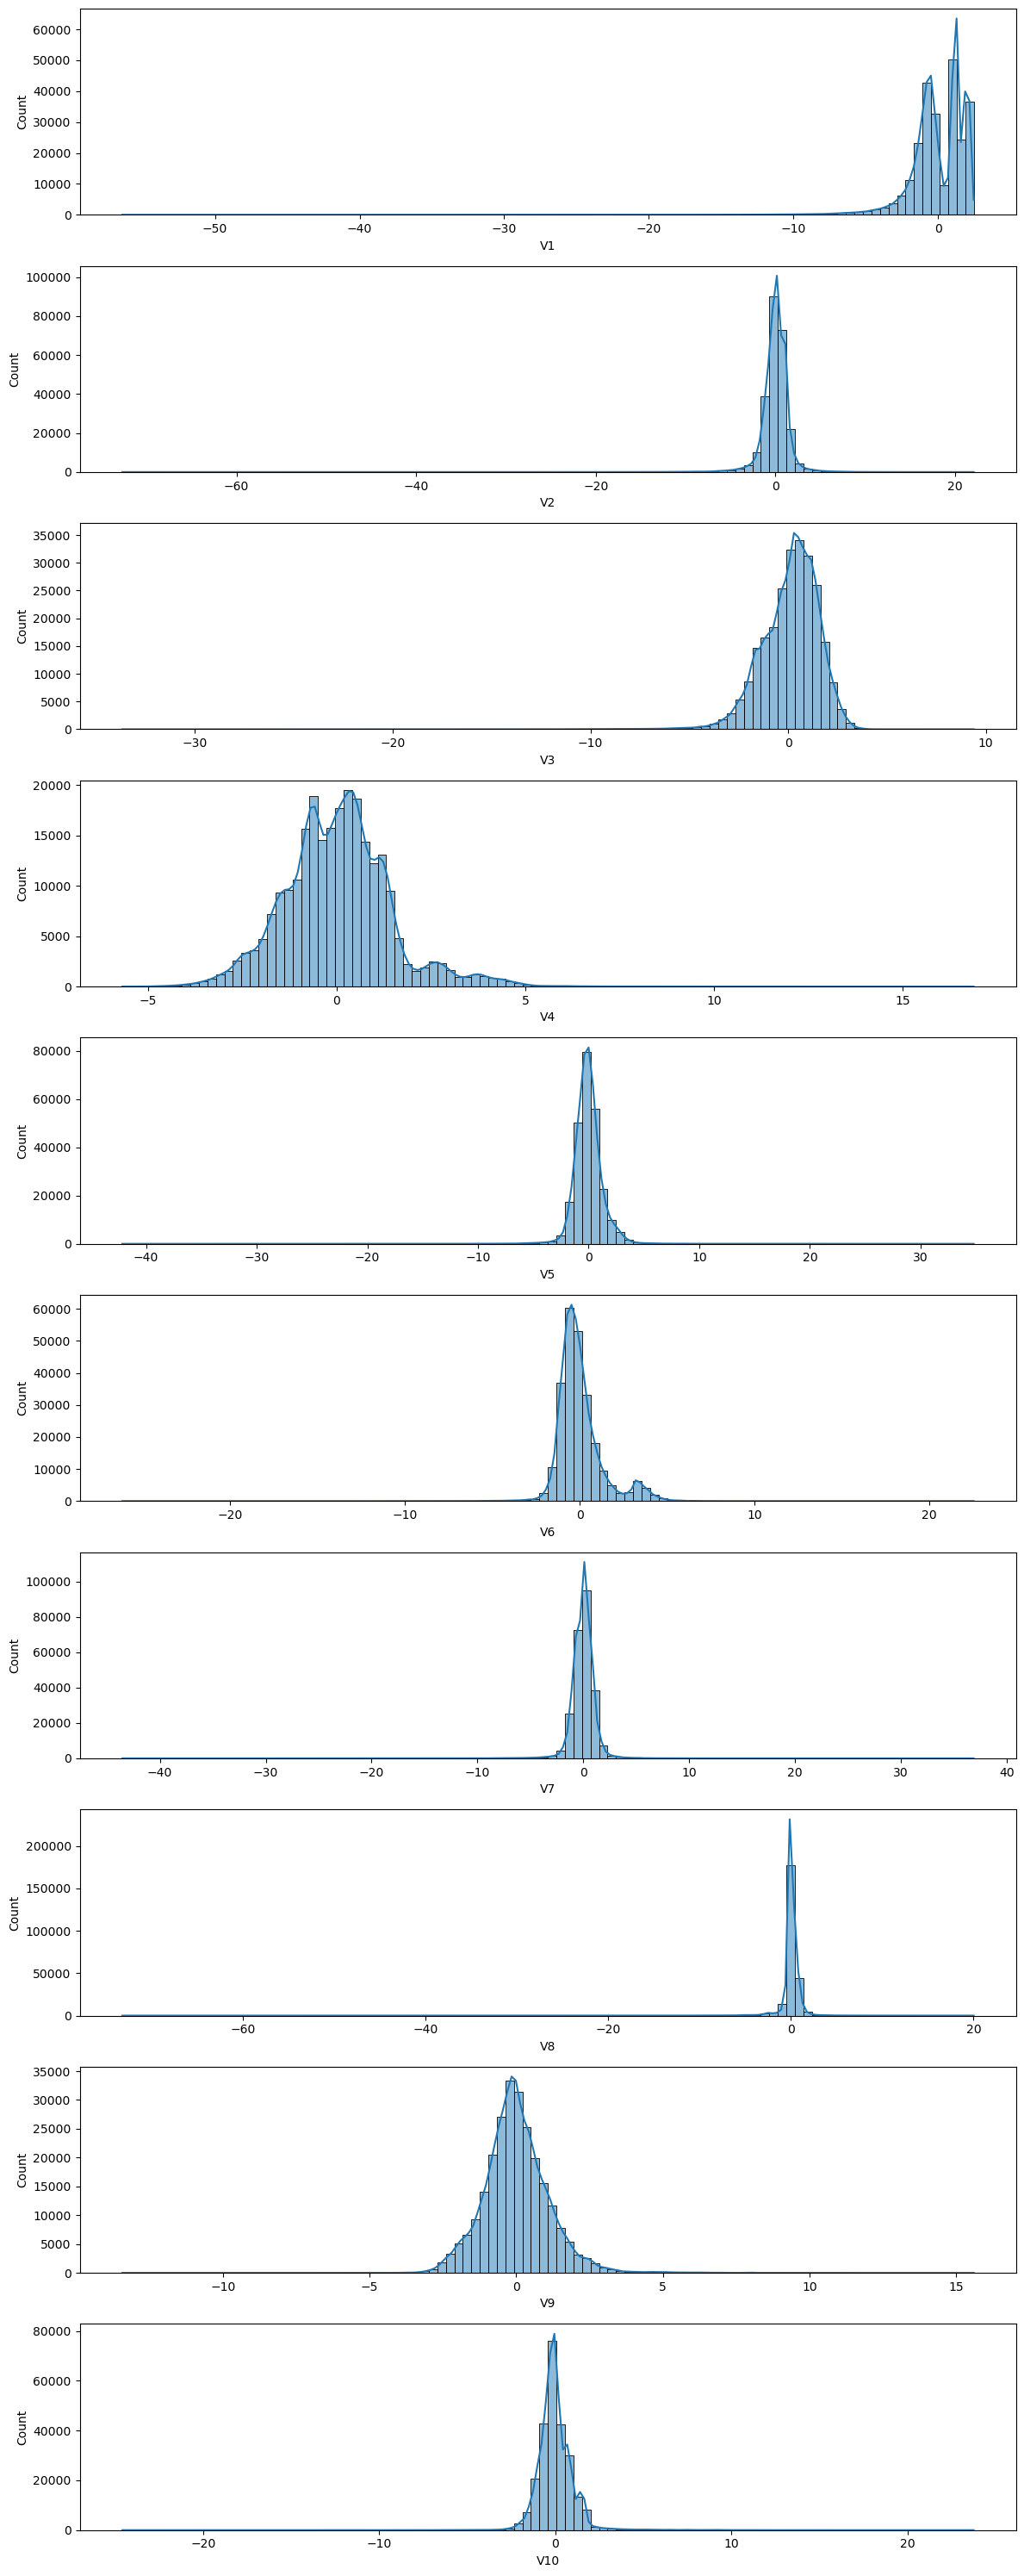

In [54]:
cols=[f'V{i}' for i in range(1,11)]
fig, axes = plt.subplots(10, 1, figsize=(12, 30))
for i,col in enumerate(cols):
    sns.histplot(data=df, x=col, ax=axes.flatten()[i], bins=100, kde=True)
plt.tight_layout()
plt.show()

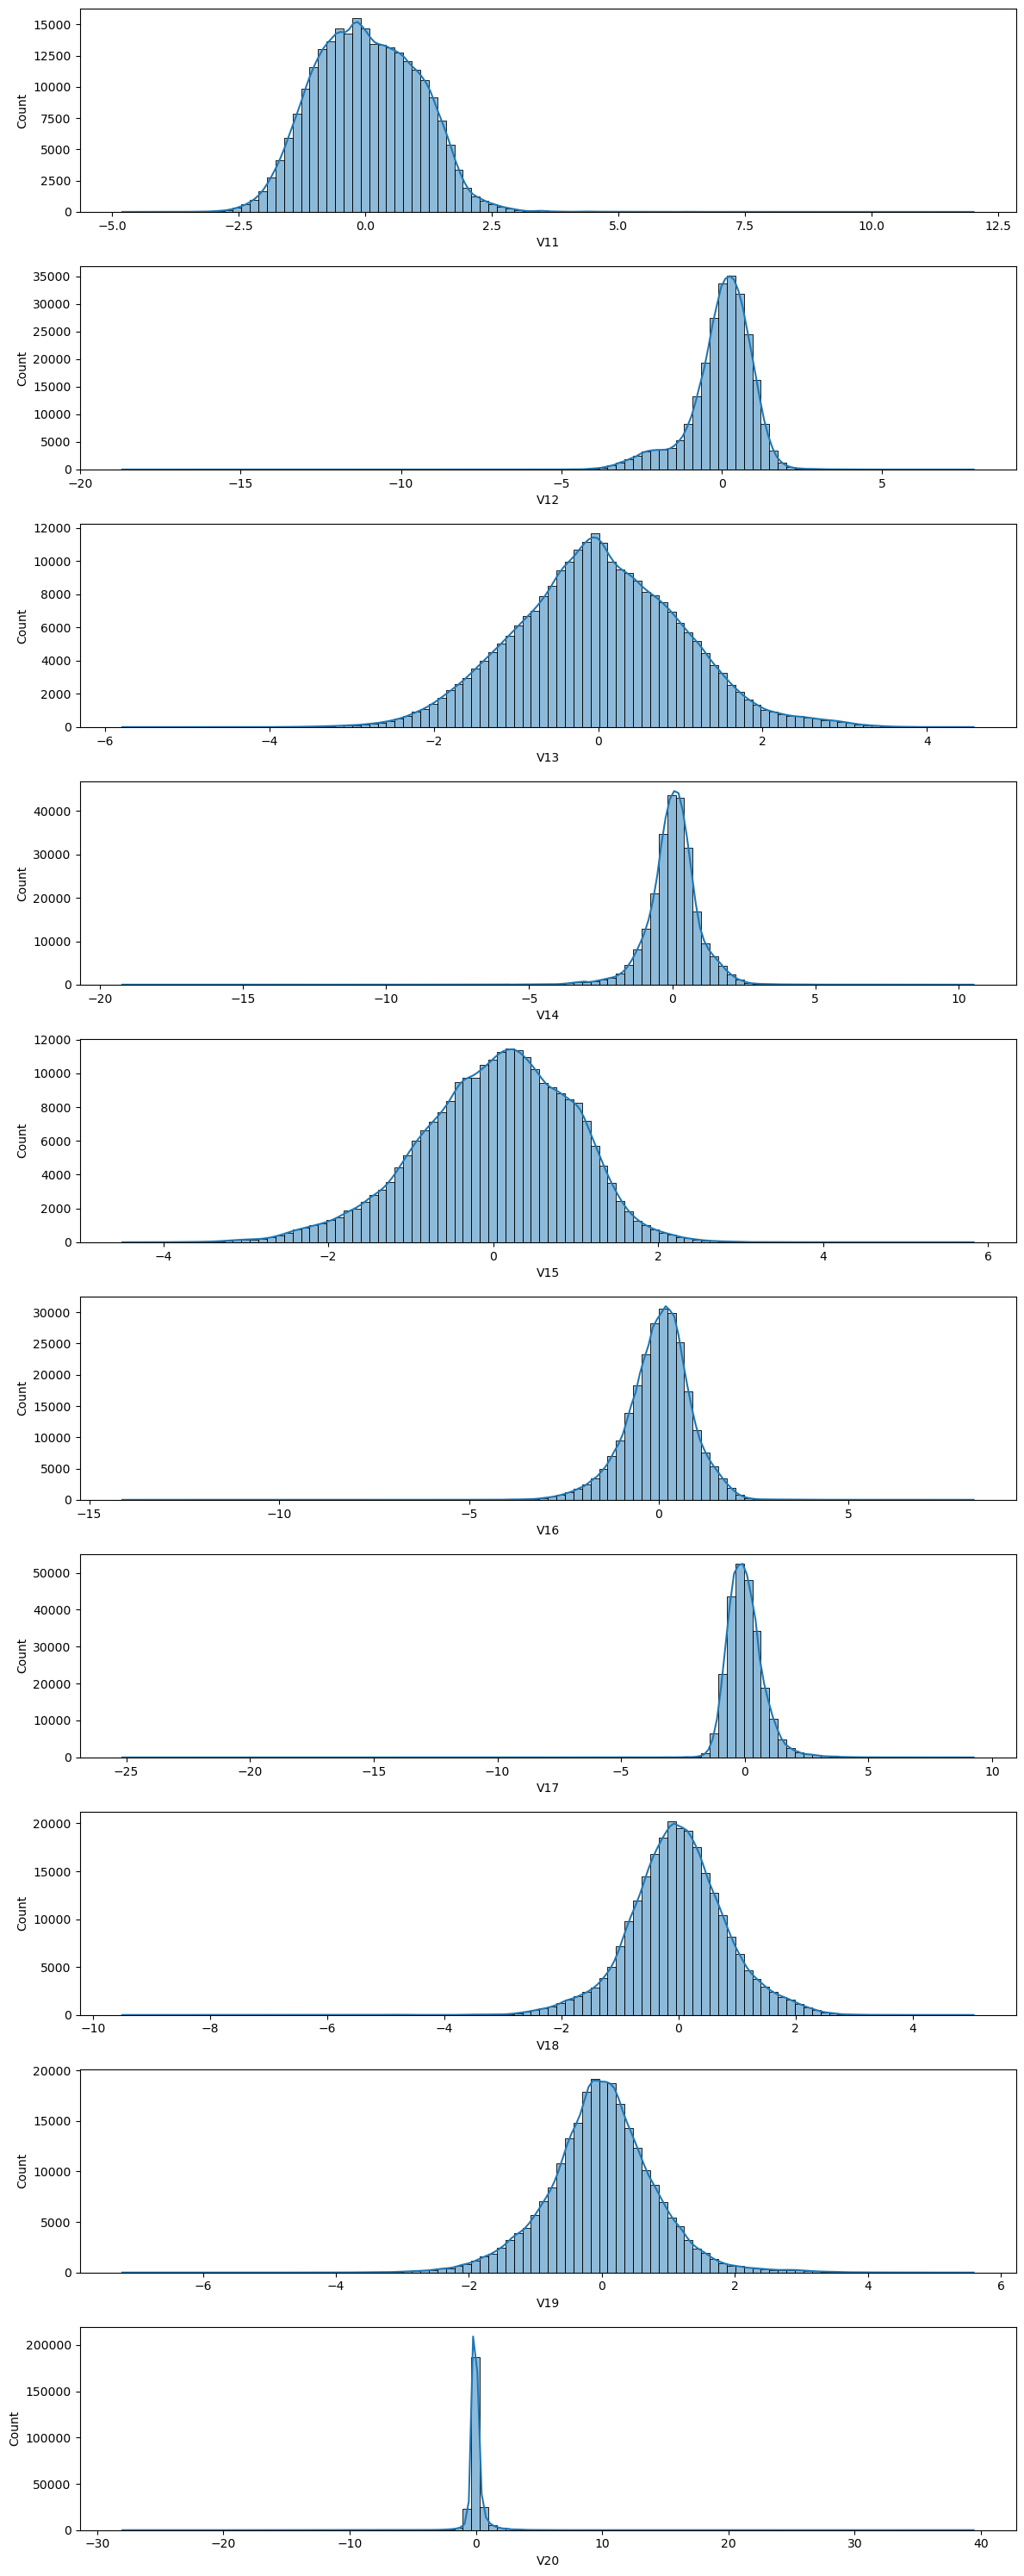

In [37]:
cols=[f'V{i}' for i in range(11,21)]
fig, axes = plt.subplots(10, 1, figsize=(12, 30))
for i,col in enumerate(cols):
    sns.histplot(data=df, x=col, ax=axes.flatten()[i], bins=100, kde=True)
plt.tight_layout()
plt.show()

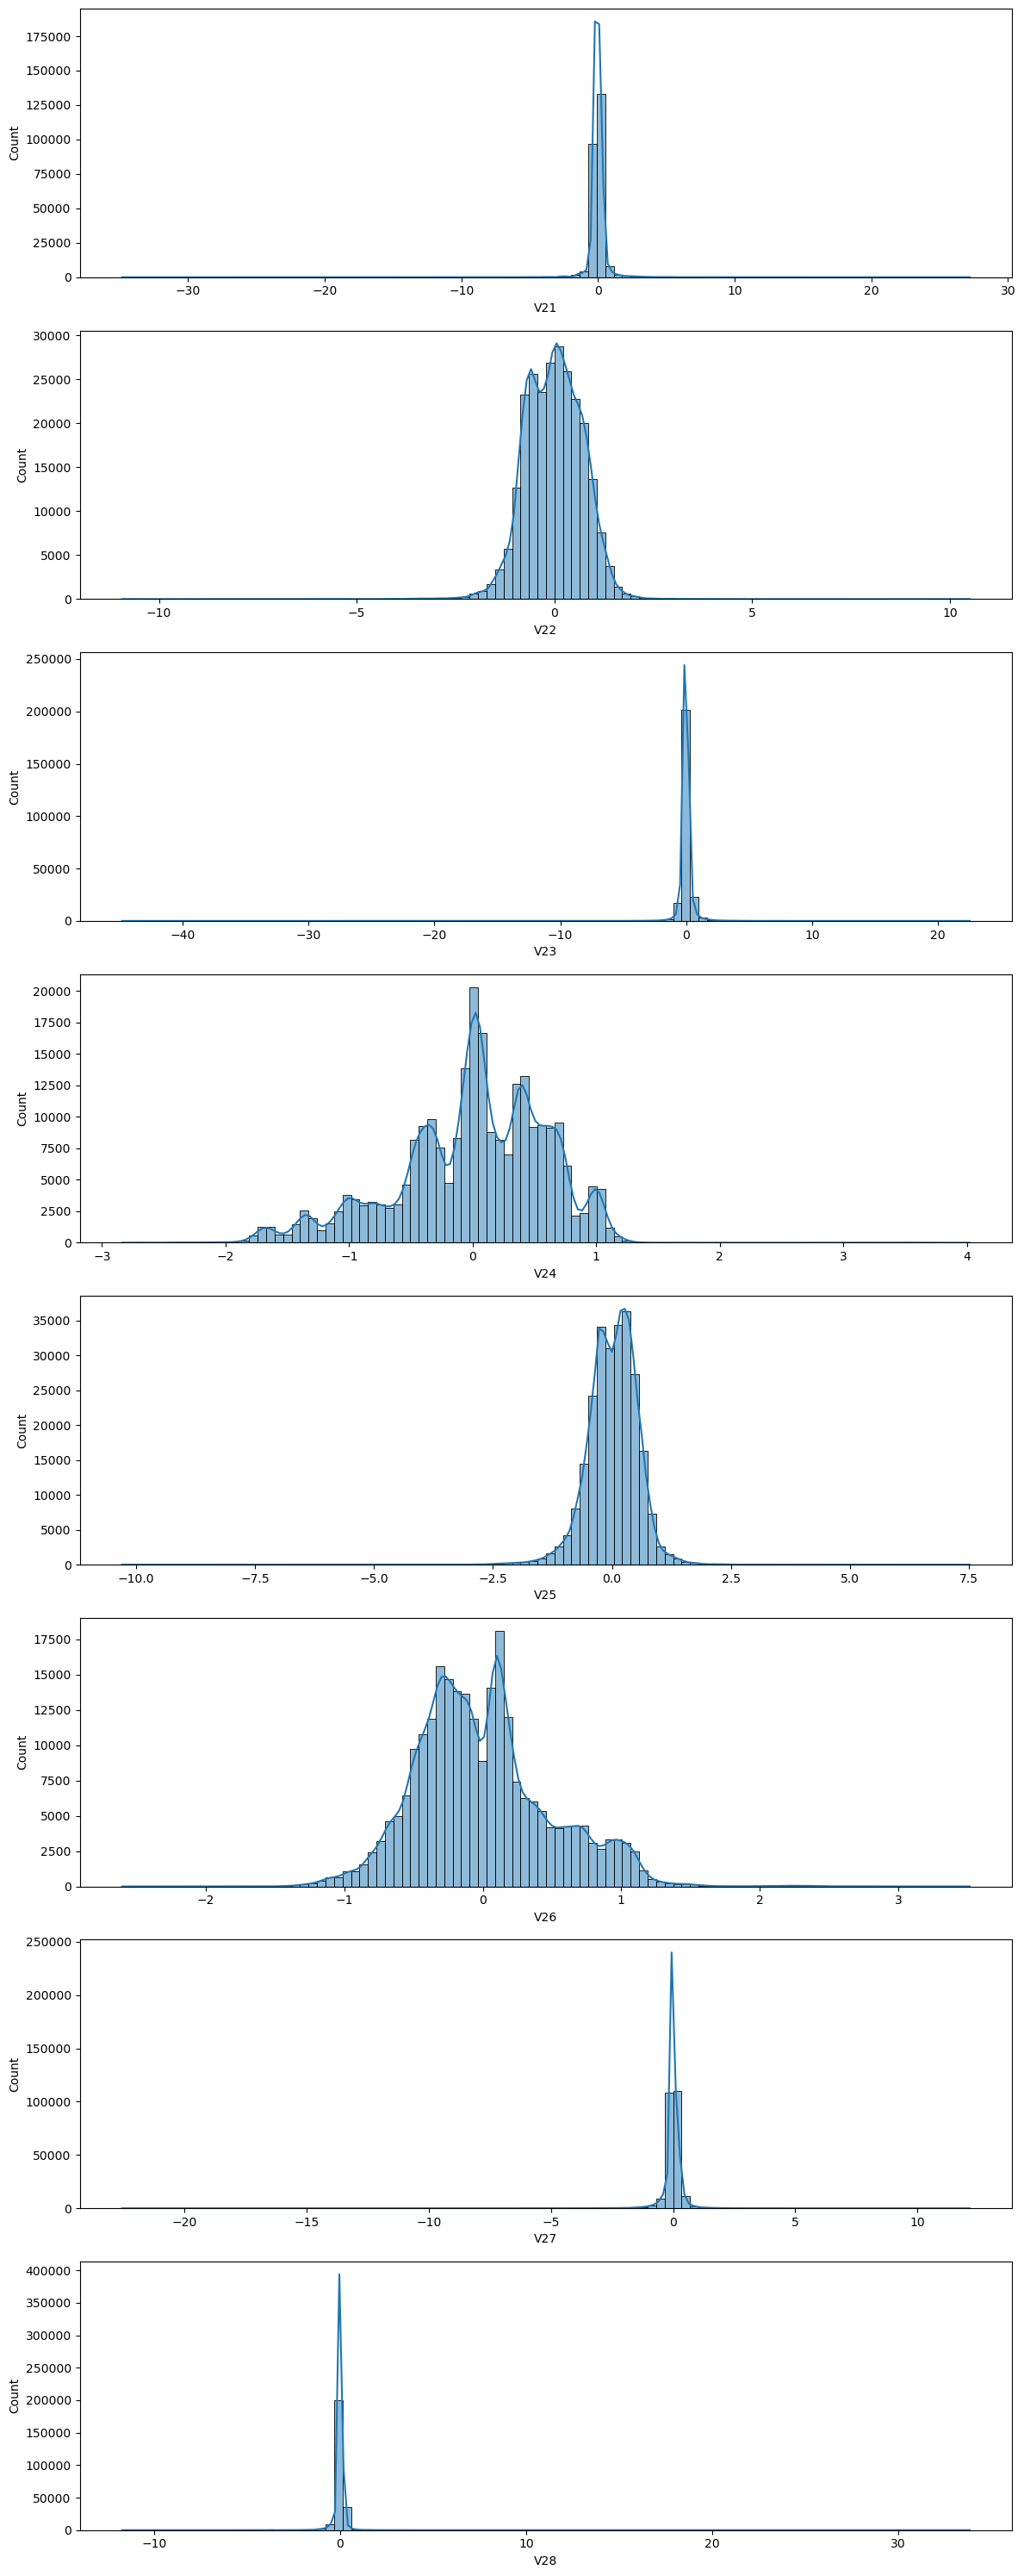

In [38]:
cols=[f'V{i}' for i in range(21,29)]
fig, axes = plt.subplots(8, 1, figsize=(12, 30))
for i,col in enumerate(cols):
    sns.histplot(data=df, x=col, ax=axes.flatten()[i], bins=100, kde=True)
plt.tight_layout()
plt.show()

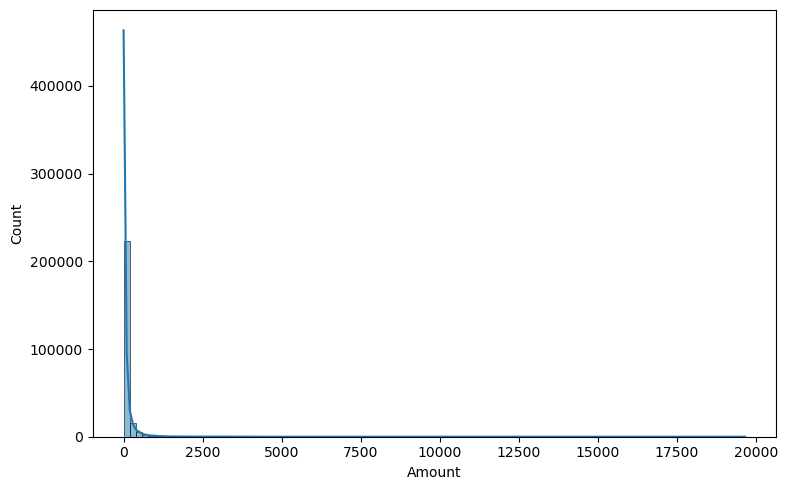

In [39]:
fig, axes = plt.subplots(figsize=(8, 5))
sns.histplot(data=df, x='Amount', kde=True, bins=100, ax=axes)
plt.tight_layout()
plt.show()

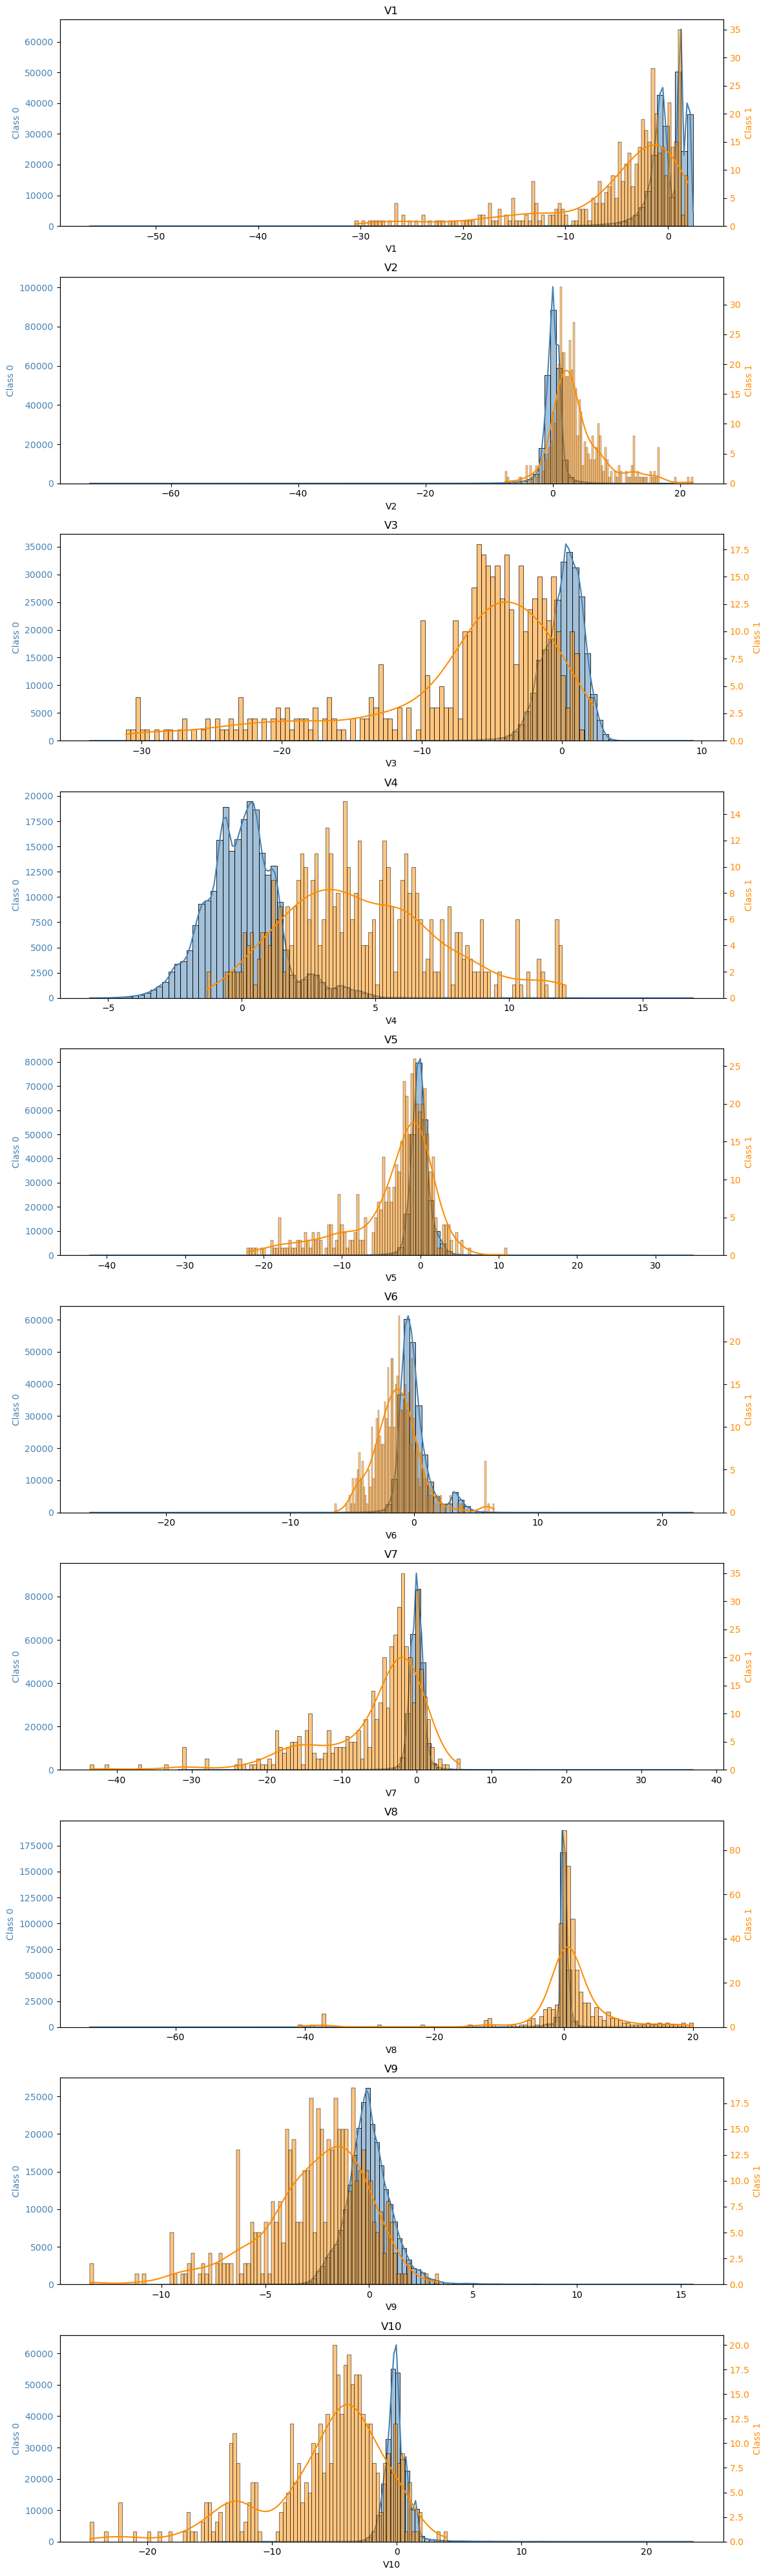

In [40]:
cols=[f'V{i}' for i in range(1,11)]
fig, axes = plt.subplots(10, 1, figsize=(12, 40))
axes_flat = axes.flatten()

for i, col in enumerate(cols):
    ax_left = axes_flat[i]
    sns.histplot(
        data=df[df["Class"] == 0],
        x=col,
        ax=ax_left,
        bins=100,
        kde=True,
        color="steelblue",
        label="Klasa 0",
    )
    ax_left.set_ylabel("Class 0", color="steelblue")
    ax_left.tick_params(axis="y", labelcolor="steelblue")

    ax_right = ax_left.twinx()

    sns.histplot(
        data=df[df["Class"] == 1],
        x=col,
        ax=ax_right,
        bins=100,
        kde=True,
        color="darkorange",
        label="Klasa 1",
    )
    ax_right.set_ylabel("Class 1", color="darkorange")
    ax_right.tick_params(axis="y", labelcolor="darkorange")

    ax_left.set_title(f"{col}")

plt.tight_layout()
plt.show()

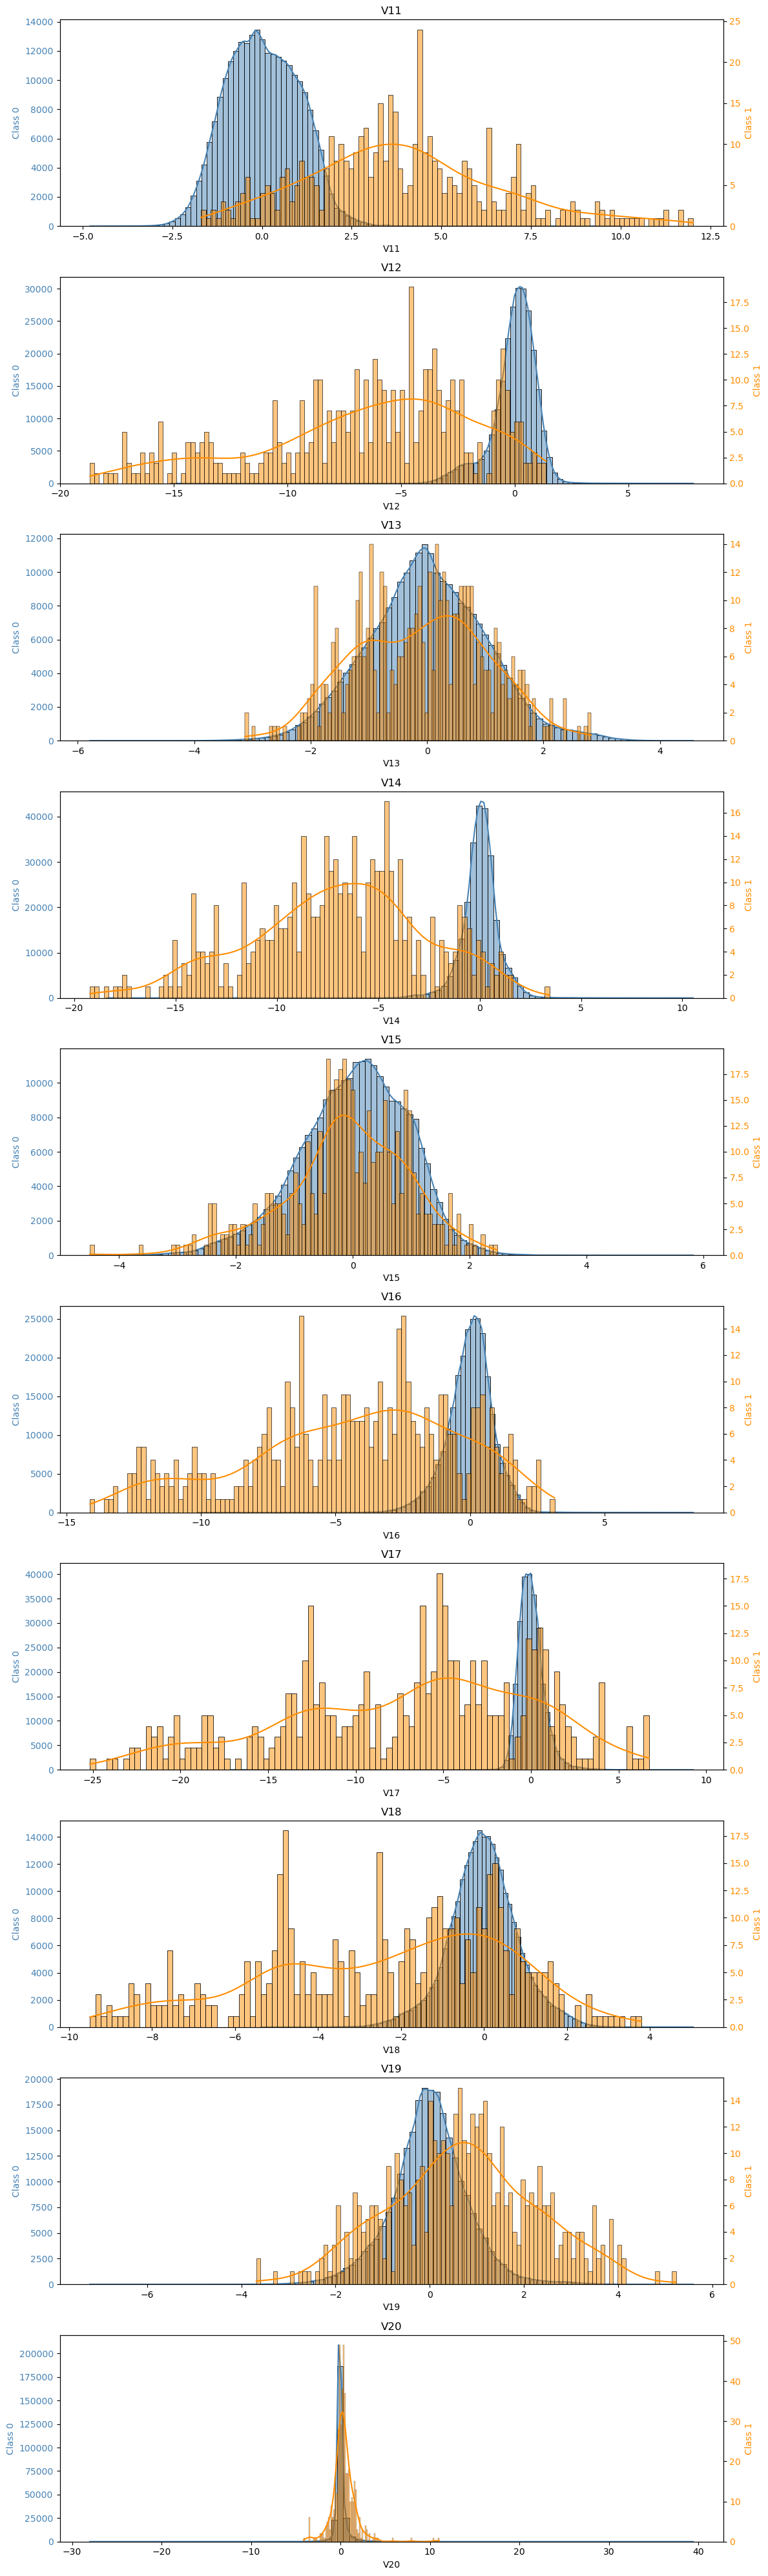

In [41]:
cols=[f'V{i}' for i in range(11,21)]
fig, axes = plt.subplots(10, 1, figsize=(12, 40))
axes_flat = axes.flatten()

for i, col in enumerate(cols):
    ax_left = axes_flat[i]
    sns.histplot(
        data=df[df["Class"] == 0],
        x=col,
        ax=ax_left,
        bins=100,
        kde=True,
        color="steelblue",
        label="Klasa 0",
    )
    ax_left.set_ylabel("Class 0", color="steelblue")
    ax_left.tick_params(axis="y", labelcolor="steelblue")

    ax_right = ax_left.twinx()

    sns.histplot(
        data=df[df["Class"] == 1],
        x=col,
        ax=ax_right,
        bins=100,
        kde=True,
        color="darkorange",
        label="Klasa 1",
    )
    ax_right.set_ylabel("Class 1", color="darkorange")
    ax_right.tick_params(axis="y", labelcolor="darkorange")

    ax_left.set_title(f"{col}")

plt.tight_layout()
plt.show()

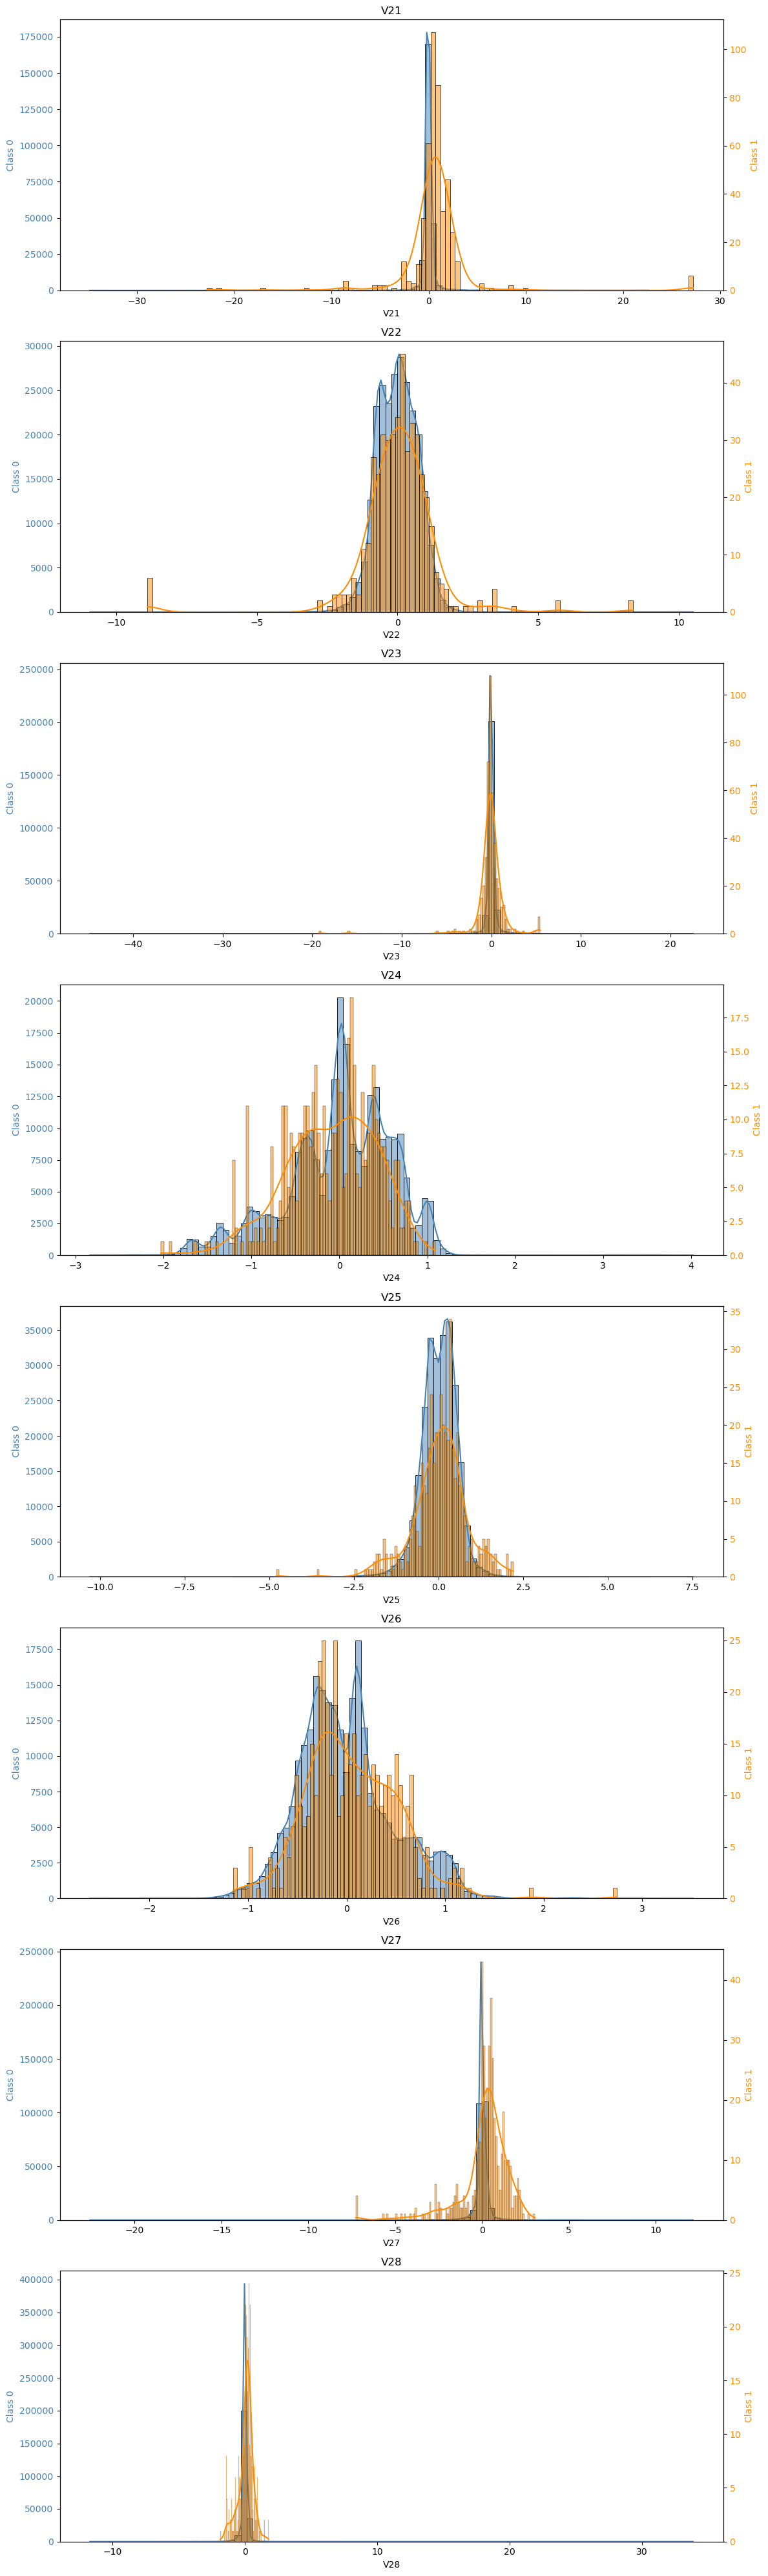

In [42]:
cols=[f'V{i}' for i in range(21,29)]
fig, axes = plt.subplots(8, 1, figsize=(12, 40))
axes_flat = axes.flatten()

for i, col in enumerate(cols):
    ax_left = axes_flat[i]
    sns.histplot(
        data=df[df["Class"] == 0],
        x=col,
        ax=ax_left,
        bins=100,
        kde=True,
        color="steelblue",
        label="Klasa 0",
    )
    ax_left.set_ylabel("Class 0", color="steelblue")
    ax_left.tick_params(axis="y", labelcolor="steelblue")

    ax_right = ax_left.twinx()

    sns.histplot(
        data=df[df["Class"] == 1],
        x=col,
        ax=ax_right,
        bins=100,
        kde=True,
        color="darkorange",
        label="Klasa 1",
    )
    ax_right.set_ylabel("Class 1", color="darkorange")
    ax_right.tick_params(axis="y", labelcolor="darkorange")

    ax_left.set_title(f"{col}")

plt.tight_layout()
plt.show()

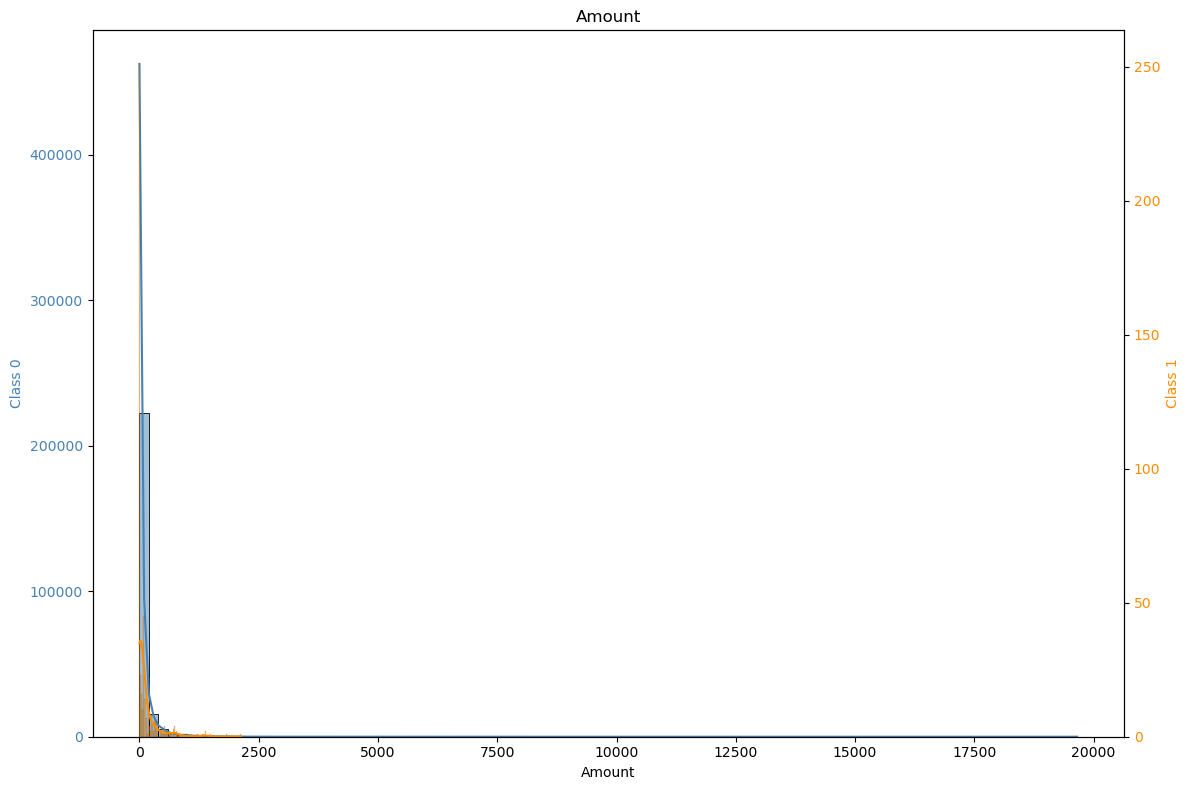

In [43]:
fig, axes = plt.subplots(figsize=(12, 8))
axes_flat = axes

ax_left = axes_flat
sns.histplot(
    data=df[df["Class"] == 0],
    x='Amount',
    ax=ax_left,
    bins=100,
    kde=True,
    color="steelblue",
    label="Klasa 0",
)
ax_left.set_ylabel("Class 0", color="steelblue")
ax_left.tick_params(axis="y", labelcolor="steelblue")

ax_right = ax_left.twinx()

sns.histplot(
    data=df[df["Class"] == 1],
    x='Amount',
    ax=ax_right,
    bins=100,
    kde=True,
    color="darkorange",
    label="Klasa 1",
)
ax_right.set_ylabel("Class 1", color="darkorange")
ax_right.tick_params(axis="y", labelcolor="darkorange")

ax_left.set_title(f"Amount")

plt.tight_layout()
plt.show()

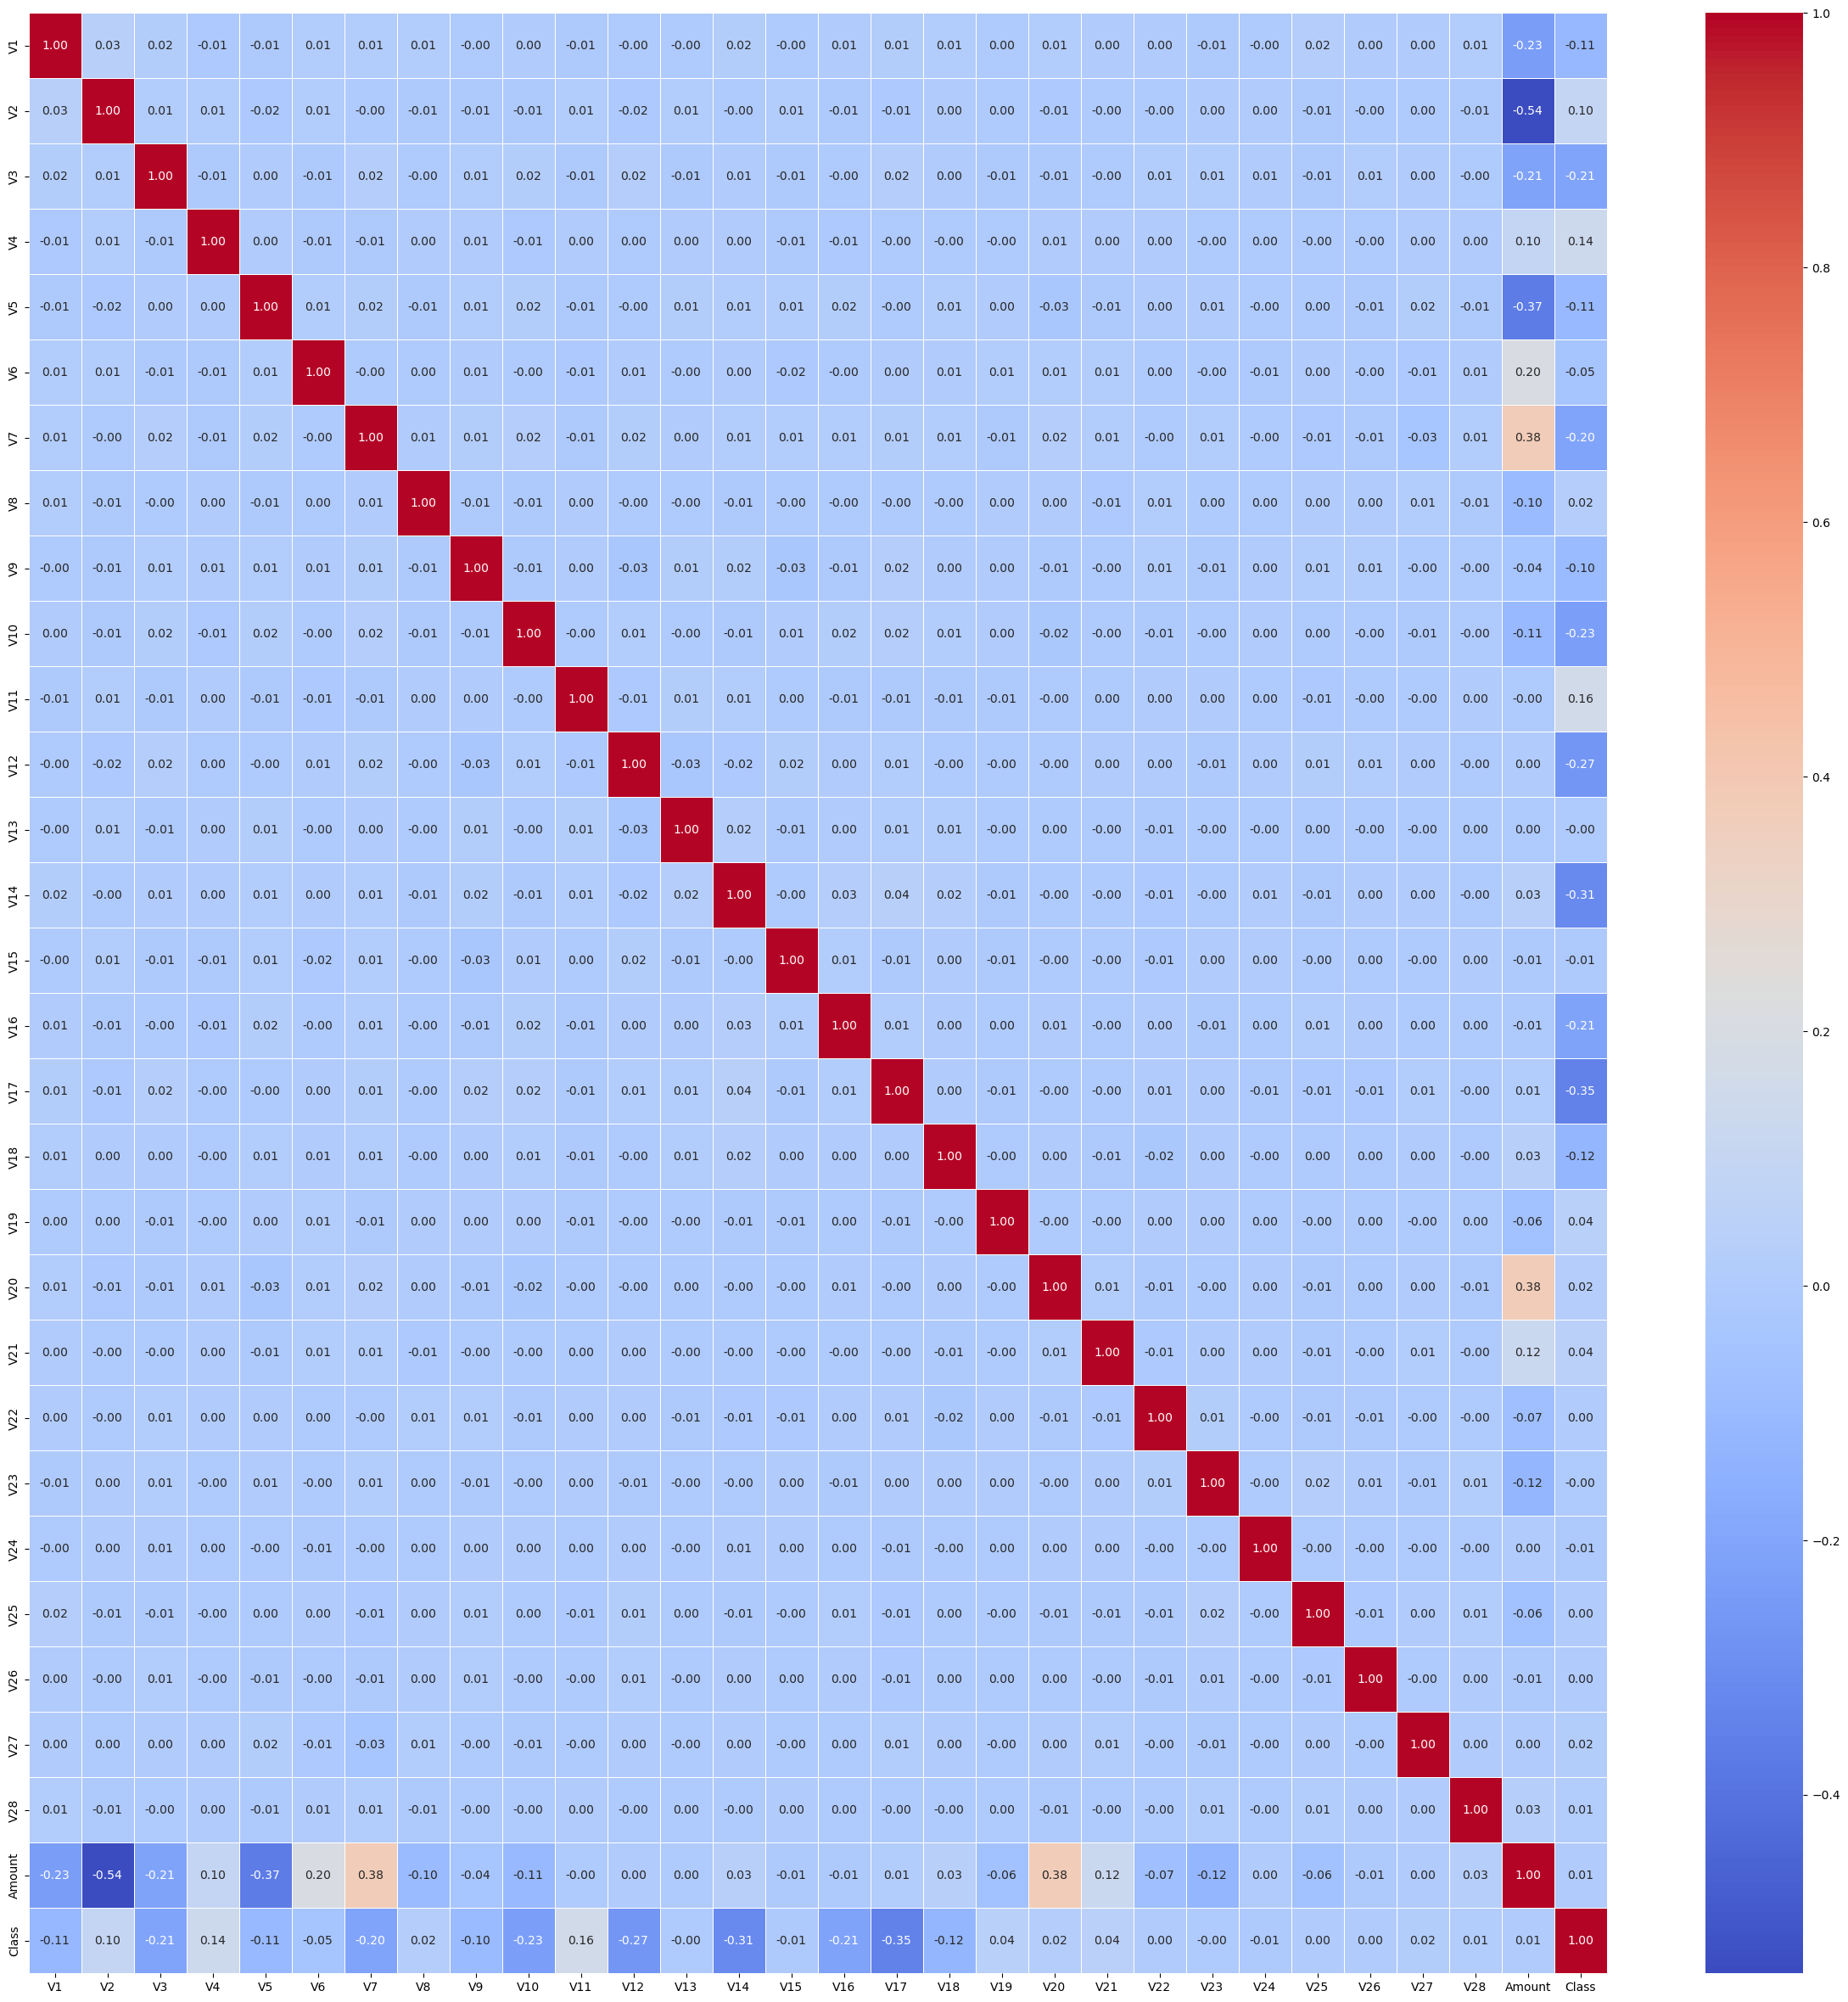

In [52]:
fig, axes = plt.subplots(figsize=(30, 30))
sns.heatmap(df.drop(columns=['Time']).corr(), cmap='coolwarm', fmt=".2f", linewidths=0.5, ax=axes, annot=True)
plt.show()

# After EDA I will select features V1, V2, V3, V4, V5, V7, V9, V10, V11, V12, V14, V16, V17, V18 for modeling.